In [28]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

In [29]:
dp_cols = ['OII3726_DP', 'OII3729_DP',
        'Hbeta_DP',
        'OIII4959_DP', 'OIII5007_DP',
        'NII6548_DP', 'NII6583_DP', 'Halpha_DP',
        'SII6716_DP', 'SII6731_DP']
dp_rank_cols = [f'{col[:-3]}_rank' for col in dp_cols]

In [30]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0315_dps_test.fits')
cs_df, model_1comp_cs, left_2comp_cs, right_2comp_cs = DP.extract_fits_data('./catalogs/0315_nbcs_test.fits')

stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
cs_df = pd.merge(cs_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')

dps_df.drop(columns=dp_cols+['MORPHTYPE', 'P_VALUE', 'BPT_1COMP'], inplace=True)
cs_df.drop(columns=['MORPHTYPE', 'P_VALUE', 'DV_R', 'DV_L', 'SIGMA_L', 'SIGMA_R'], inplace=True)

In [31]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}
# dps_df['BPT_2comp'] = dps_df['BPT_2comp'].map(classification_map)
# cs_df['BPT_1comp'] = cs_df['BPT_1comp'].map(classification_map)

In [32]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


In [33]:
# robust_dps = dps_df[(dps_df['BPT_2comp']!=512)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_2COMP']!=512)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())]

# robust_cs = cs_df[(cs_df['BPT_1comp']!=256)&(cs_df['VD_SL']!=0)&(cs_df['LOGM']!=0)]
robust_cs = cs_df[(cs_df['BPT_1COMP']!=256)&(cs_df['LOGM']!=0)]

In [34]:
print(len(robust_dps), len(robust_cs))

13948 10419


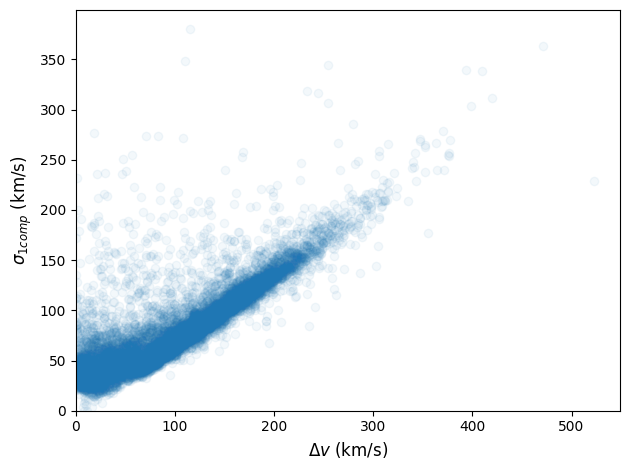

In [35]:
plt.scatter(robust_dps['delta_dv'], robust_dps['SIGMA_1COMP'], alpha=0.05)
# plt.scatter(robust_cs['LOGM'], robust_cs['sigma_1comp'], alpha=0.05)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$\Delta v$ (km/s)', fontsize=12)
plt.ylabel(r'$\sigma_{1comp}$ (km/s)', fontsize=12)
plt.tight_layout()
# plt.savefig('./figures/Feb25/delta_v_vs_sigma_1comp.png')
plt.show()

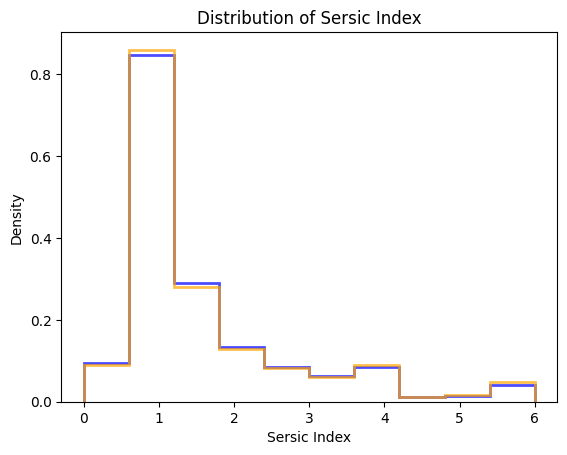

In [36]:
plt.hist(dps_df['SERSIC'], density=True, range=(0, 6), alpha=0.7, label='DP', histtype='step', linewidth=2, color='blue')
plt.hist(cs_df['SERSIC'], density=True, range=(0, 6), alpha=0.7, label='CS', histtype='step', linewidth=2, color='orange')
plt.xlabel('Sersic Index')
plt.ylabel('Density')
plt.title('Distribution of Sersic Index')
plt.show()

In [37]:
def find_pairs(df_1, df_2, physical_sep_kpc=50, avoid_self=True):
    initial_sep_threshold_arcsec = 100.0  # A generous initial search radius in arcseconds
    z_sep_upper_threshold = 0.01 # delta_z
    z_sep_lower_threshold = 0.00000 # delta_z
    physical_sep_kpc = physical_sep_kpc # kpc


    coords_1 = SkyCoord(ra=df_1['RA'].values*u.degree, dec=df_1['DEC'].values*u.degree)
    coords_2 = SkyCoord(ra=df_2['RA'].values*u.degree, dec=df_2['DEC'].values*u.degree)

    idx2, idx1, sep2d, _ = coords_1.search_around_sky(coords_2, initial_sep_threshold_arcsec*u.arcsec)
    
    # Filter out self-matches
    if avoid_self:
        unique_pairs_mask = idx1 < idx2
        idx1 = idx1[unique_pairs_mask]
        idx2 = idx2[unique_pairs_mask]
        sep2d = sep2d[unique_pairs_mask]

    # Create a DataFrame of potential pairs
    pair_candidates = pd.DataFrame({
        'idx1': idx1,
        'idx2': idx2,
        'separation_arcsec': sep2d.arcsec
    })
    # Get redshifts for the pairs
    z1 = df_1['Z'].values[pair_candidates['idx1']]
    z2 = df_2['Z'].values[pair_candidates['idx2']]
    pair_candidates['z_diff'] = np.abs(z1 - z2)
    pair_candidates['z_mean'] = (z1 + z2) / 2.0

    pair_candidates = pair_candidates[(pair_candidates['z_mean']>0.03)&(pair_candidates['z_diff']>1e-4)].copy()

    # Filter by redshift difference first
    close_z_pairs_df = pair_candidates[(pair_candidates['z_diff'] < z_sep_upper_threshold) & (pair_candidates['z_diff'] > z_sep_lower_threshold)].copy()

    # Calculate the dynamic angular separation threshold for each pair based on its mean redshift
    # This threshold corresponds to the defined physical separation
    with np.errstate(divide='ignore'): # Ignore division by zero for z=0
        angular_sep_threshold_deg = (physical_sep_kpc / cosmo.kpc_proper_per_arcmin(close_z_pairs_df['z_mean']) / 60.0).value

    # Convert the dynamic threshold to arcseconds
    close_z_pairs_df['dynamic_sep_threshold_arcsec'] = angular_sep_threshold_deg * 3600

    # Filter pairs based on the dynamic angular separation threshold
    close_pairs_df = close_z_pairs_df[close_z_pairs_df['separation_arcsec'] < close_z_pairs_df['dynamic_sep_threshold_arcsec']].reset_index(drop=True)

    # Calculate the physical separation in kpc
    with np.errstate(divide='ignore'):
        kpc_per_arcmin = cosmo.kpc_proper_per_arcmin(close_pairs_df['z_mean']).value
    close_pairs_df['physical_separation_kpc'] = (close_pairs_df['separation_arcsec'] / 60.0) * kpc_per_arcmin
    close_pairs_df = close_pairs_df[close_pairs_df['physical_separation_kpc']>3]
    
    
    # Add TARGETID to the final close pairs dataframe
    close_pairs_df['TARGETID1'] = df_1['TARGETID'].values[close_pairs_df['idx1']]
    close_pairs_df['TARGETID2'] = df_2['TARGETID'].values[close_pairs_df['idx2']]

    close_pairs_df['LOGM_1'] = df_1['LOGM'].values[close_pairs_df['idx1']]
    close_pairs_df['LOGM_2'] = df_2['LOGM'].values[close_pairs_df['idx2']]

    close_pairs_df.drop(columns=['idx1', 'idx2', 'dynamic_sep_threshold_arcsec', 'z_mean'], inplace=True)
    return close_pairs_df


# DP+DP Pairs

In [38]:
dpdp_df = find_pairs(robust_dps, robust_dps, physical_sep_kpc=50, avoid_self=True)
dpdp_df['BPT_1'] = dpdp_df['TARGETID1'].map(robust_dps.set_index('TARGETID')['BPT_2COMP'])
dpdp_df['BPT_2'] = dpdp_df['TARGETID2'].map(robust_dps.set_index('TARGETID')['BPT_2COMP'])
dpdp_df['delta_v_1'] = dpdp_df['TARGETID1'].map(robust_dps.set_index('TARGETID')['delta_dv'])
dpdp_df['delta_v_2'] = dpdp_df['TARGETID2'].map(robust_dps.set_index('TARGETID')['delta_dv'])
# dpdp_df['delta_v_2'] = dpdp_df['TARGETID2'].map(robust_dps.set_index('TARGETID')['delta_dv'])

print(f"Found {len(dpdp_df)} close pairs.")
print("Catalog of close pairs:")
dpdp_df.sort_values(by='physical_separation_kpc', ascending=True).head()

Found 90 close pairs.
Catalog of close pairs:


,separation_arcsec,z_diff,physical_separation_kpc,TARGETID1,TARGETID2,LOGM_1,LOGM_2,BPT_1,BPT_2,delta_v_1,delta_v_2
13,2.089046,0.000643,3.278026,39627751459653321,39627751459653339,10.491512,9.803169,5,17,182.256622,64.577087
50,1.812788,0.000346,4.316609,39627782317151127,39627782317151146,10.017331,9.965467,20,8,222.772720,132.837830
18,2.785714,0.000488,4.329246,39627751891670645,39627751891670649,8.794398,9.492950,2,2,8.110003,6.655901
54,9.383385,0.000960,6.211973,39627788344364226,39627788344364285,10.089719,10.061767,17,2,10.541977,108.559822
51,4.302929,0.000179,6.399672,39627782434589057,39627782434589075,10.085723,10.057607,32,32,157.230743,94.125473


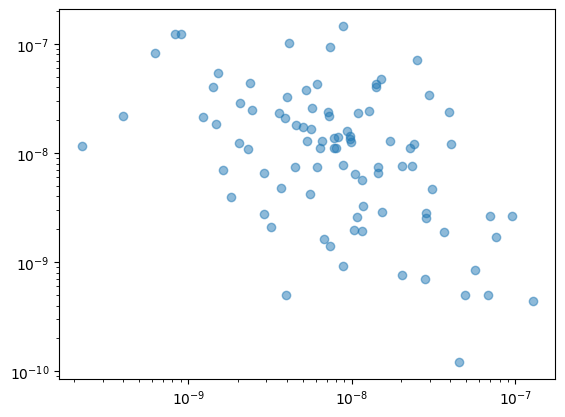

In [39]:

plt.scatter(dpdp_df['delta_v_2']/10**dpdp_df['LOGM_1'], dpdp_df['delta_v_1']/10**dpdp_df['LOGM_2'], alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.show()

# CS+CS Pairs

In [40]:
cscs_df = find_pairs(robust_cs, robust_cs, physical_sep_kpc=50, avoid_self=True)
cscs_df['BPT_1'] = cscs_df['TARGETID1'].map(robust_cs.set_index('TARGETID')['BPT_1COMP'])
cscs_df['BPT_2'] = cscs_df['TARGETID2'].map(robust_cs.set_index('TARGETID')['BPT_1COMP'])
cscs_df['delta_v_1'] = cscs_df['TARGETID1'].map(robust_cs.set_index('TARGETID')['SIGMA_1COMP'])
cscs_df['delta_v_2'] = cscs_df['TARGETID2'].map(robust_cs.set_index('TARGETID')['SIGMA_1COMP'])

print(f"Found {len(cscs_df)} close pairs.")
print("Catalog of close pairs:")
cscs_df.sort_values(by='physical_separation_kpc', ascending=True).head()

Found 55 close pairs.
Catalog of close pairs:


,separation_arcsec,z_diff,physical_separation_kpc,TARGETID1,TARGETID2,LOGM_1,LOGM_2,BPT_1,BPT_2,delta_v_1,delta_v_2
46,2.195161,0.000368,3.969876,39627817914208263,39627817914208265,10.004472,7.834216,1,1,96.684586,39.182686
49,2.627523,0.000223,5.150014,39627818283306531,39627818283306534,8.784520,9.712712,1,1,53.032280,41.604343
12,4.302929,0.000179,6.399672,39627782434589057,39627782434589075,10.085723,10.057607,16,16,97.131523,61.046112
34,2.184294,0.000307,7.710481,39627805855581827,39627805855581842,9.930966,10.030507,1,1,77.343559,75.469650
3,6.346517,0.000390,9.826103,39627776285742032,39627776285742064,10.660561,10.422320,1,16,129.744156,153.947113


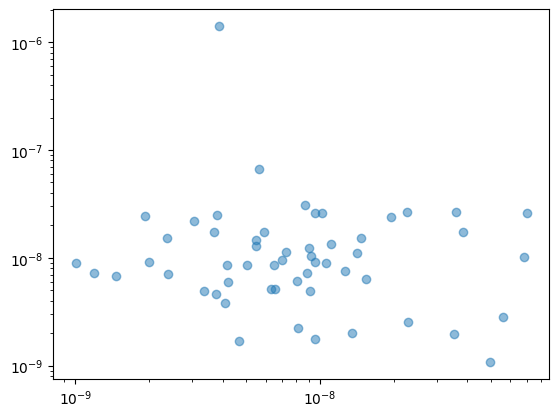

In [41]:
plt.scatter(cscs_df['delta_v_2']/10**cscs_df['LOGM_1'], cscs_df['delta_v_1']/10**cscs_df['LOGM_2'], alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.show()

# DP+CS Pairs

In [42]:
dpcs_df = find_pairs(robust_dps, robust_cs, physical_sep_kpc=50, avoid_self=False)
dpcs_df['BPT_1'] = dpcs_df['TARGETID1'].map(robust_dps.set_index('TARGETID')['BPT_2COMP'])
dpcs_df['BPT_2'] = dpcs_df['TARGETID2'].map(robust_cs.set_index('TARGETID')['BPT_1COMP'])
dpcs_df['delta_v_1'] = dpcs_df['TARGETID1'].map(robust_dps.set_index('TARGETID')['delta_dv'])
dpcs_df['delta_v_2'] = dpcs_df['TARGETID2'].map(robust_cs.set_index('TARGETID')['SIGMA_1COMP'])


print(f"Found {len(dpcs_df)} close pairs.")
print("Catalog of close pairs:")
dpcs_df.sort_values(by='LOGM_1', ascending=False).head(10)

Found 102 close pairs.
Catalog of close pairs:


,separation_arcsec,z_diff,physical_separation_kpc,TARGETID1,TARGETID2,LOGM_1,LOGM_2,BPT_1,BPT_2,delta_v_1,delta_v_2
86,3.480011,0.001715,10.291717,39627812600023547,39627812600023565,11.073242,10.260994,8,16,212.625183,118.769264
23,4.450371,0.000192,19.490234,39627788067537626,39627788067537603,11.053720,10.682670,8,16,351.843231,154.610718
82,10.249719,0.000282,20.181928,39627812398694725,39627812398694756,10.895995,10.428620,2,1,293.511047,115.742210
24,3.113741,0.000437,12.017628,39627788210145152,39627788210145157,10.767488,10.249987,2,1,104.149597,107.978477
60,2.777400,0.001263,12.879311,39627805847195921,39627805847195935,10.737180,10.527349,5,1,338.781647,64.853294
100,8.075636,0.000241,31.767176,39627824088222848,39627824088222824,10.721322,10.397909,8,4,162.596741,89.729767
4,6.346517,0.000390,9.826103,39627776285742032,39627776285742064,10.660561,10.422320,2,16,197.581680,153.947113
35,17.971256,0.000196,47.286918,39627794019256348,39627794019256257,10.590311,10.584718,32,4,213.141327,178.241837
36,17.971260,0.000196,47.286927,39627794019256257,39627794019256348,10.584718,10.590311,17,16,163.708145,145.008423
27,10.850533,0.000854,32.614718,39627793780179989,39627793780180036,10.572681,9.700666,2,1,171.081711,72.356323


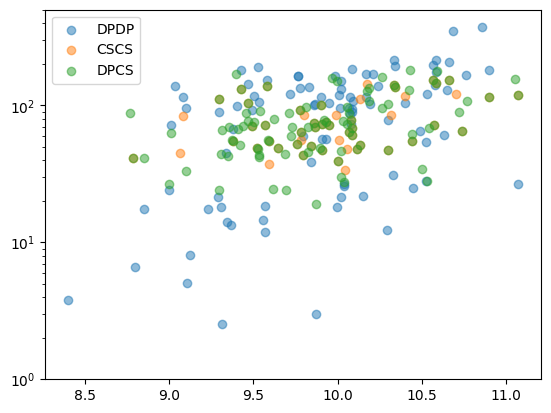

In [43]:
# plt.scatter(robust_dps['LOGM'], robust_dps['delta_dv'], alpha=0.05, label='DP', color='gray')
plt.scatter(dpdp_df['LOGM_1'], dpdp_df['delta_v_2'], alpha=0.5, label='DPDP')
plt.scatter(cscs_df['LOGM_1'], cscs_df['delta_v_2'], alpha=0.5, label='CSCS')
plt.scatter(dpcs_df['LOGM_1'], dpcs_df['delta_v_2'], alpha=0.5, label='DPCS')
# plt.xscale('log')
plt.yscale('log')
plt.ylim((1e0, 5e2))
plt.legend()
plt.show()

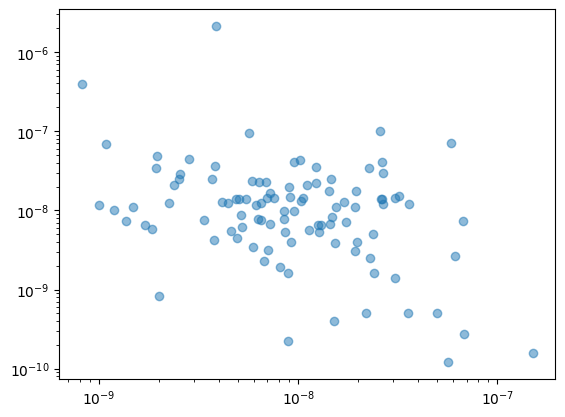

In [44]:
plt.scatter(dpcs_df['delta_v_2']/10**dpcs_df['LOGM_1'], dpcs_df['delta_v_1']/10**dpcs_df['LOGM_2'], alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.show()

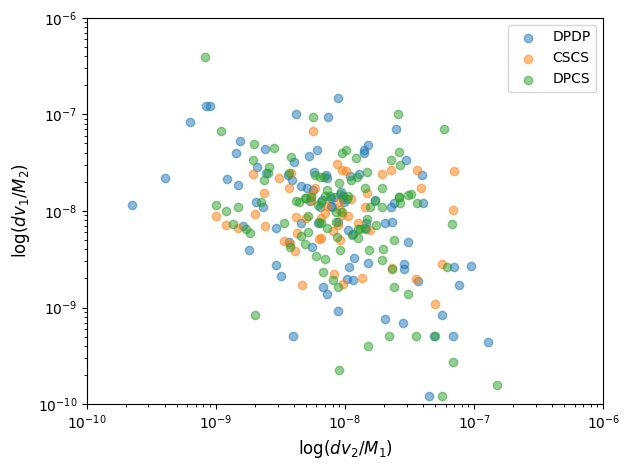

In [45]:
plt.scatter(dpdp_df['delta_v_2']/10**dpdp_df['LOGM_1'], dpdp_df['delta_v_1']/10**dpdp_df['LOGM_2'], alpha=0.5, label='DPDP', color='C0')
plt.scatter(cscs_df['delta_v_2']/10**cscs_df['LOGM_1'], cscs_df['delta_v_1']/10**cscs_df['LOGM_2'], alpha=0.5, label='CSCS', color='C1')
plt.scatter(dpcs_df['delta_v_2']/10**dpcs_df['LOGM_1'], dpcs_df['delta_v_1']/10**dpcs_df['LOGM_2'], alpha=0.5, label='DPCS', color='C2')
plt.xscale('log')
plt.yscale('log')
plt.xlim((1e-10, 1e-6))
plt.ylim((1e-10, 1e-6))
plt.xlabel(r'log($dv_2 / M_1$)', fontsize=12)
plt.ylabel(r'log($dv_1 / M_2$)', fontsize=12)
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/dv1M2_vs_dv2M1.png')
plt.show()

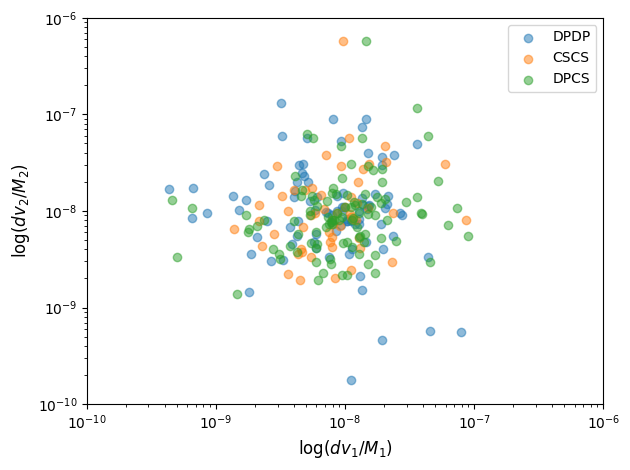

In [46]:
plt.scatter(dpdp_df['delta_v_1']/10**dpdp_df['LOGM_1'], dpdp_df['delta_v_2']/10**dpdp_df['LOGM_2'], alpha=0.5, label='DPDP')
plt.scatter(cscs_df['delta_v_1']/10**cscs_df['LOGM_1'], cscs_df['delta_v_2']/10**cscs_df['LOGM_2'], alpha=0.5, label='CSCS')
plt.scatter(dpcs_df['delta_v_1']/10**dpcs_df['LOGM_1'], dpcs_df['delta_v_2']/10**dpcs_df['LOGM_2'], alpha=0.5, label='DPCS')
plt.xscale('log')
plt.yscale('log')
plt.xlim((1e-10, 1e-6))
plt.ylim((1e-10, 1e-6))
plt.xlabel(r'log($dv_1 / M_1$)', fontsize=12)
plt.ylabel(r'log($dv_2 / M_2$)', fontsize=12)
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/dv1M1_vs_dv2M2.png')
plt.show()

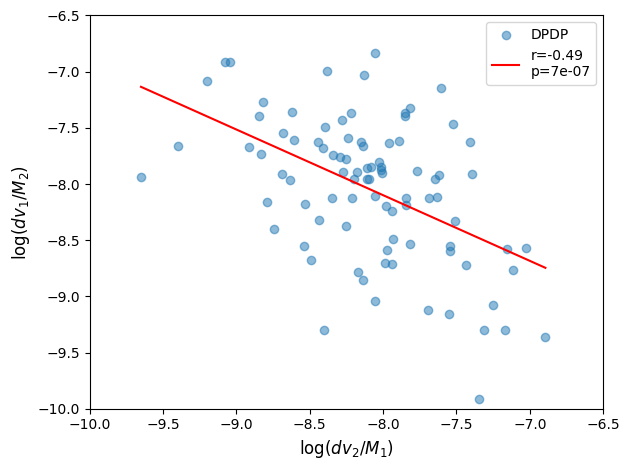

In [47]:
from scipy import stats
from scipy.stats import spearmanr
# Prepare the data from the previous plot, using log scale
x_data = np.log10(dpdp_df['delta_v_2'] / 10**dpdp_df['LOGM_1'])
y_data = np.log10(dpdp_df['delta_v_1'] / 10**dpdp_df['LOGM_2'])

# Remove any non-finite values to ensure the fit can be calculated
valid_data = pd.DataFrame({'x': x_data, 'y': y_data}).dropna()
valid_data = valid_data[np.isfinite(valid_data).all(1)]

# Filter data within a given range. You can change the range as needed.
x_min, x_max = -10., -6.5
y_min, y_max = -10., -6.5
fit_data = valid_data[(valid_data['x'] >= x_min) & (valid_data['x'] <= x_max) & 
                      (valid_data['y'] >= y_min) & (valid_data['y'] <= y_max)]
# fit_data = valid_data.copy() # Use all valid data for fitting if you don't want to filter by range

# Perform linear regression on the filtered data
slope, intercept, correlation, p_value, std_err = stats.linregress(fit_data['x'], fit_data['y'])
# correlation, p_value = spearmanr(fit_data['x'], fit_data['y'])

# Create the scatter plot of all valid data
plt.scatter(valid_data['x'], valid_data['y'], alpha=0.5, label='DPDP', color='C0')


# Create the fit line
fit_x = np.linspace(fit_data['x'].min(), fit_data['x'].max(), 100)
fit_y = slope * fit_x + intercept
plt.plot(fit_x, fit_y, color='red', label=f'r={correlation:.2f}\np={p_value:.0e}')

# Set plot labels and title
plt.xlabel(r'log($dv_2 / M_1$)', fontsize=12)
plt.ylabel(r'log($dv_1 / M_2$)', fontsize=12)
# plt.title('Linear Fit of Delta DV Scatter')
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/cscs_fit.png')
plt.show()

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_38136/1272597140.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1]) # Adjust layout to make room for colorbar


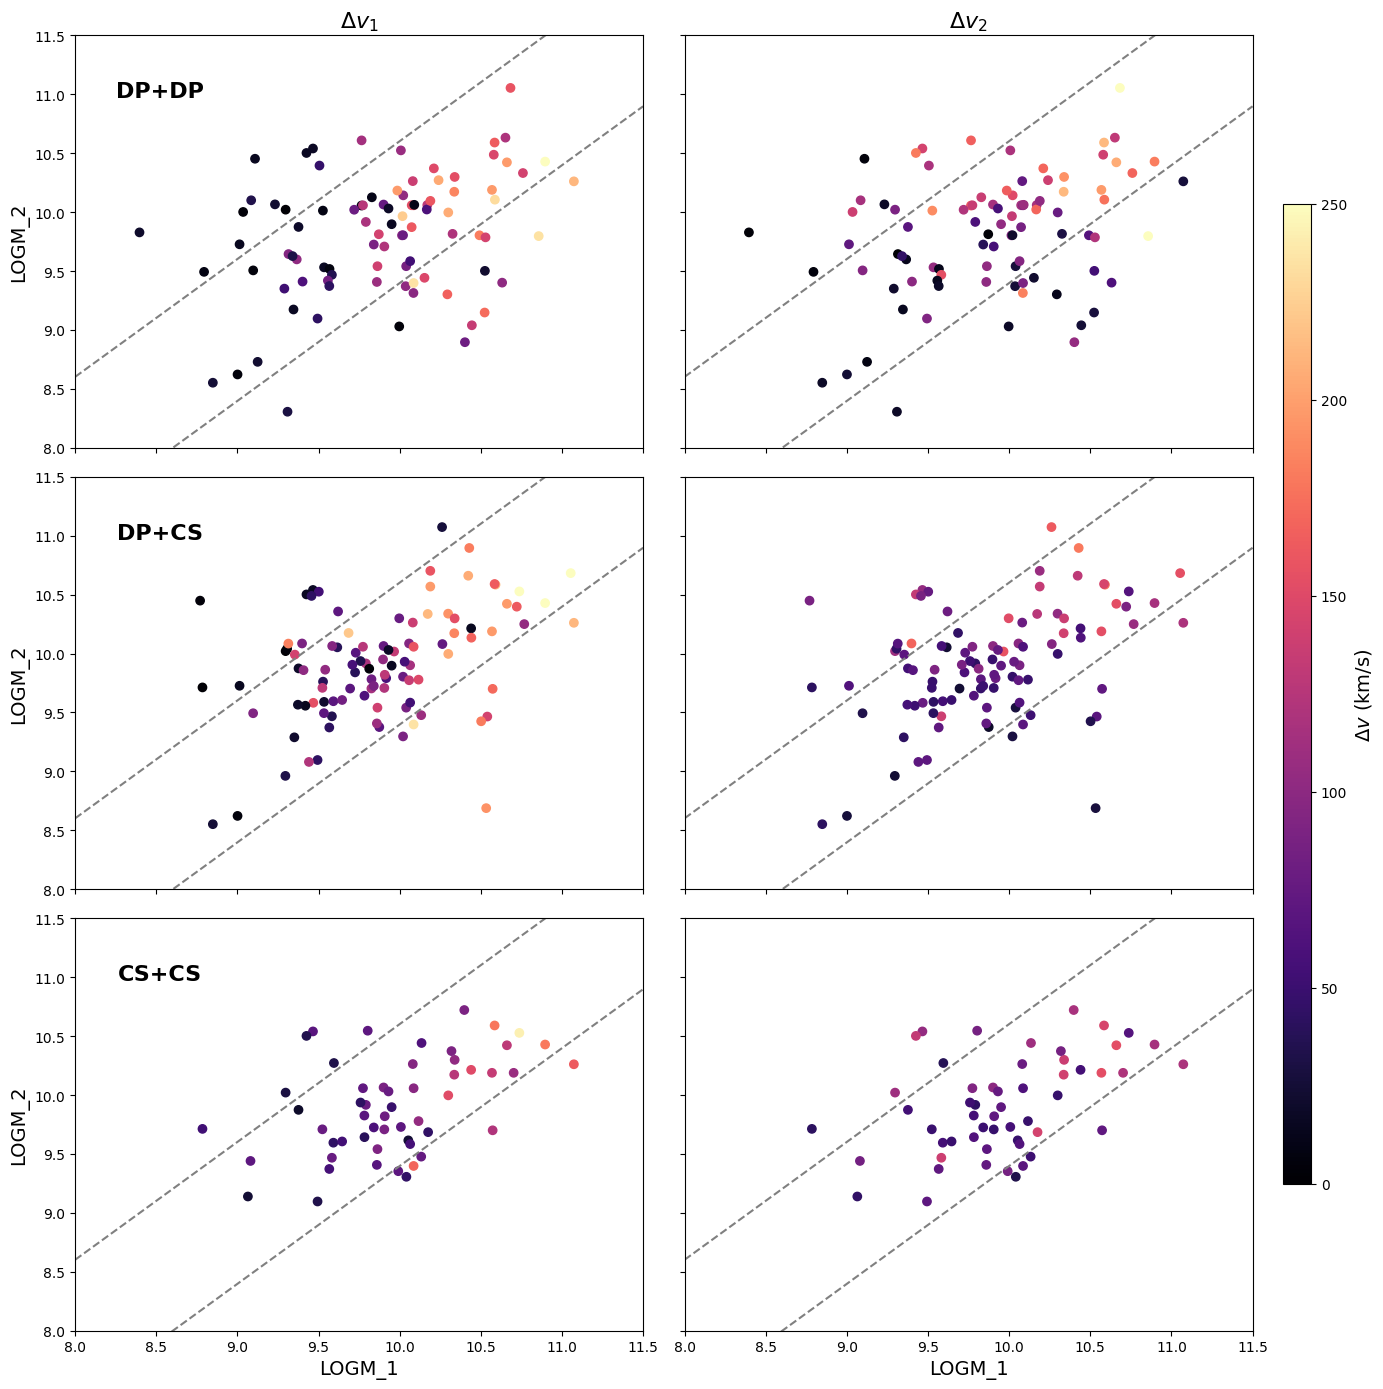

In [89]:
fig, ax = plt.subplots(3, 2, figsize=(14, 14), sharex=True, sharey=True)
plt.subplots_adjust(wspace=-0.1, hspace=-0.1)

x = np.linspace(8, 11.5, 100)
y_1 = x + np.log10(1/4)
y_2 = x + np.log10(4)

texts = ['DP+DP', 'DP+CS', 'CS+CS']
sc_list = []

for i, df in enumerate([dpdp_df, dpcs_df, cscs_df]):
    sc1 = ax[i, 0].scatter(df['LOGM_1'], df['LOGM_2'], c=df['delta_v_1'], cmap='magma', vmin=0, vmax=250)
    sc_list.append(sc1)
    ax[i, 0].text(0.15, 0.85, texts[i], transform=ax[i, 0].transAxes, ha='center', fontsize=16, weight='bold')
    ax[i, 0].plot(x, y_1, linestyle='--', color='gray')
    ax[i, 0].plot(x, y_2, linestyle='--', color='gray')
    ax[i, 0].set_xlim(8, 11.5)
    ax[i, 0].set_ylim(8, 11.5)

    sc2 = ax[i, 1].scatter(df['LOGM_1'], df['LOGM_2'], c=df['delta_v_2'], cmap='magma', vmin=0, vmax=250)
    sc_list.append(sc2)
    ax[i, 1].plot(x, y_1, linestyle='--', color='gray')
    ax[i, 1].plot(x, y_2, linestyle='--', color='gray')
    ax[i, 1].set_xlim(8, 11.5)
    ax[i, 1].set_ylim(8, 11.5)

ax[0, 0].set_title(r'$\Delta v_1$', fontsize=16)
ax[0, 1].set_title(r'$\Delta v_2$', fontsize=16)

ax[0, 0].set_ylabel('LOGM_2', fontsize=14)
ax[1, 0].set_ylabel('LOGM_2', fontsize=14)
ax[2, 0].set_ylabel('LOGM_2', fontsize=14)
ax[2, 0].set_xlabel('LOGM_1', fontsize=14)
ax[2, 1].set_xlabel('LOGM_1', fontsize=14)

# Add a single colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sc_list[0], cax=cbar_ax)
cbar.set_label(r'$\Delta v$ (km/s)', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.92, 1]) # Adjust layout to make room for colorbar
plt.savefig('./figures/Mar26/dv1_dv2_scatter.png')
plt.show()


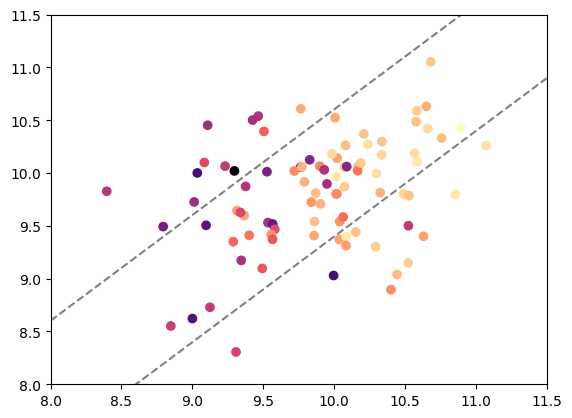

In [ ]:

plt.scatter(dpdp_df['LOGM_1'], dpdp_df['LOGM_2'], c=np.log10(dpdp_df['delta_v_1']), cmap='magma')
plt.plot(x, y_1, linestyle='--', color='gray')
plt.plot(x, y_2, linestyle='--', color='gray')
plt.xlim(8, 11.5)
plt.ylim(8, 11.5)
plt.show()

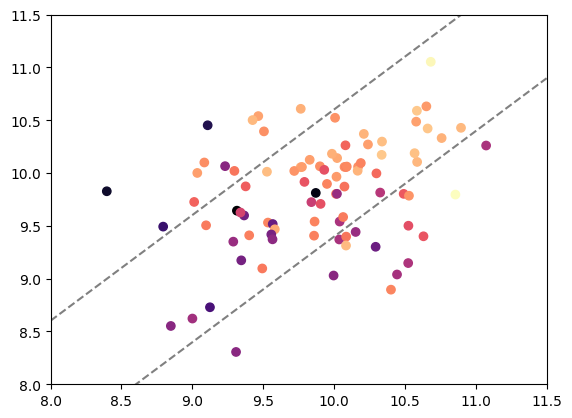

In [55]:
plt.scatter(dpdp_df['LOGM_1'], dpdp_df['LOGM_2'], c=np.log10(dpdp_df['delta_v_2']), cmap='magma')
plt.plot(x, y_1, linestyle='--', color='gray')
plt.plot(x, y_2, linestyle='--', color='gray')
plt.xlim(8, 11.5)
plt.ylim(8, 11.5)
plt.show()